<a href="https://colab.research.google.com/github/ruy00803/Employee-Attrition-Analysis-HR-Strategy-Proposal/blob/main/%E6%9E%B6%E7%A9%BA%E4%BC%81%E6%A5%AD%E3%81%AE%E8%AA%B2%E9%A1%8C%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

データセットの内容
・大手ITコンサル企業であるI社の過去の人事データで、離職したかどうかなどについて記述されている

・約1500人の従業員についてのcsvファイルが提供されている

Education

 'Below College'

 'College'

 'Bachelor'

 'Master'

 'Doctor'


EnvironmentSatisfaction

 'Low'

 'Medium'

 'High'

 'Very High'


JobInvolvement  

 'Low'

 'Medium'

 'High'

 'Very High'


JobSatisfaction  

 'Low'

 'Medium'

 'High'

 'Very High'


RelationshipSatisfaction  

 'Low'

 'Medium'

 'High'

 'Very High'


WorkLifeBalance  

 'Bad'

 'Good'

 'Better'

 'Best'


RemoteWork

‘on-site work’

‘full remote’


Incentive : rewards for performance

StressRating：Stress level evaluation by supervisors and HR, including occupational physician assessments.
1.  ‘Very Low’
3.  ‘Average’
5.  ‘Very High’


StressSelfReported：Self-reported stress level obtained from internal company stress checks.
1.  ‘Very Low’
3.  ‘Average’
5.  ‘Very High’


WelfareBenefits：Level of overall welfare benefits utilization frequency.
1.  ‘Rarely Used’
4.  ‘Very Frequently Used’


InHouseFacility：Whether an employee utilizes in-house facilities (e.g., gym, café, cafeteria) above a certain threshold.
0.  ‘No’
1.  ‘Yes’


ExternalFacility：Whether an employee utilizes external facilities (e.g., company-affiliated facilities, language schools) above a certain threshold.
0.  ‘No’
1.  ‘Yes’


ExtendedLeave：Whether an employee has taken extended leave (e.g., parental leave, maternity leave, refreshment leave, volunteer leave) for a certain period.
0.  ‘No’
1.  ‘Yes’


FlexibleWork：Whether an employee utilizes flexible working arrangements (e.g., flextime, reduced working hours) above a certain threshold.
0.  ‘No’
1.  ‘Yes’


PerformanceIndex：An index evaluating an employee's labor productivity on a 100-point score scale.

PerformanceRating：Employee performance score determined by the annual HR evaluation.

 'Low'

 'Good'

 'Excellent'

 'Outstanding'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas import DataFrame, Series
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/data.csv_最終')

In [ ]:
print(df.shape)
df.head()

(1470, 44)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


In [ ]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,PerformanceIndex,JobInvolvement,JobLevel,JobSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.895238,9.236735,2.910204,1.0,1022.185034,2.721769,65.891156,2.729932,2.074830,2.728571,...,2.824490,6922.257143,2.499320,2.500000,0.596599,0.293878,0.252381,0.551020,2.104082,2023.200000
std,9.151321,8.129551,1.025259,0.0,602.769132,1.093082,20.329428,0.711561,1.109943,1.102846,...,1.229521,1977.100821,0.883052,1.131124,0.490747,0.455692,0.434526,0.497559,0.949750,0.400136
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,0.000000,1329.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
25%,30.000000,2.000000,2.000000,1.0,486.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,2.000000,5542.250000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2023.000000
50%,36.000000,7.000000,3.000000,1.0,1018.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,6814.500000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000,2.000000,2023.000000
75%,43.000000,14.000000,4.000000,1.0,1554.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,4.000000,8264.750000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2023.000000
max,60.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,5.000000,12612.000000,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2024.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  PerformanceIndex          1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

Attrition:離職

In [ ]:
df['Incentive'].unique()

array([   0, 3431, 3681, 2521, 2496, 3325, 1583, 2596, 1530, 4651, 1602,
       1776, 1896, 3857,  547, 1749, 1207,  548, 2886, 4867, 1264, 2488,
       1441, 2744, 1862, 2506, 2084, 1383, 1744, 2454, 3222, 4585, 5244,
       1755, 3973, 3098, 1532, 1802, 3071, 1034, 4494, 3486, 2425, 3670,
        541, 1674, 2917, 2375, 2371, 1695, 3671, 3936, 2767, 2236, 3915,
       2194, 1653, 2573, 1266, 3450, 2518, 2457,  811, 2875, 2969, 3725,
       3640, 3849, 3794, 2131, 1568, 2103, 1911, 3063, 1652, 1284, 3718,
       3489, 3557, 3889, 2426, 3705, 3788, 1428, 4060, 2384, 2793, 3851,
       3384,  701, 1014, 3722, 2091, 2669, 2499, 3654, 2430, 3464, 2052,
       4692, 3105, 3744, 3027, 3338, 2924, 3392, 1321, 1627, 3527, 3778,
       3551, 2775, 2782, 3999, 3416, 1796, 2244,   72, 2721,  631, 1579,
       2359, 3638, 2695, 1803, 4592, 3283, 4179, 2928, 3184, 1791, 2241,
       2723, 2389, 3196, 1797,  240, 2020,   59, 1806, 4253, 3509, 4623,
       3032, 1740, 3975, 3444,  889,  855,  828, 32

In [ ]:
df['MonthlyIncome'].unique()

array([5224, 6863, 7612, ..., 5828, 9420, 8379])

In [ ]:
df['PerformanceIndex'].unique()

array([ 94,  61,  92,  56,  40,  79,  81,  67,  44,  84,  49,  31,  93,
        50,  51,  80,  96,  78,  45,  82,  53,  83,  58,  72,  48,  42,
        41,  86,  97,  75,  33,  37,  73,  98,  36,  47,  71,  30,  43,
        99,  59,  95,  57,  76,  87,  66,  55,  32,  52,  70,  62,  64,
        63,  60, 100,  46,  39,  77,  35,  91,  54,  34,  90,  65,  88,
        85,  89,  68,  69,  74,  38])

In [ ]:
df['PerformanceRating'].unique()

array([1, 4, 3, 2])

/tmp/ipython-input-7-2810465097.py:29: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.tight_layout() # レイアウトを自動調整
/tmp/ipython-input-7-2810465097.py:29: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.tight_layout() # レイアウトを自動調整
/tmp/ipython-input-7-2810465097.py:29: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) DejaVu Sans.
  fig.tight_layout() # レイアウトを自動調整
/tmp/ipython-input-7-2810465097.py:29: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.tight_layout() # レイアウトを自動調整
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  

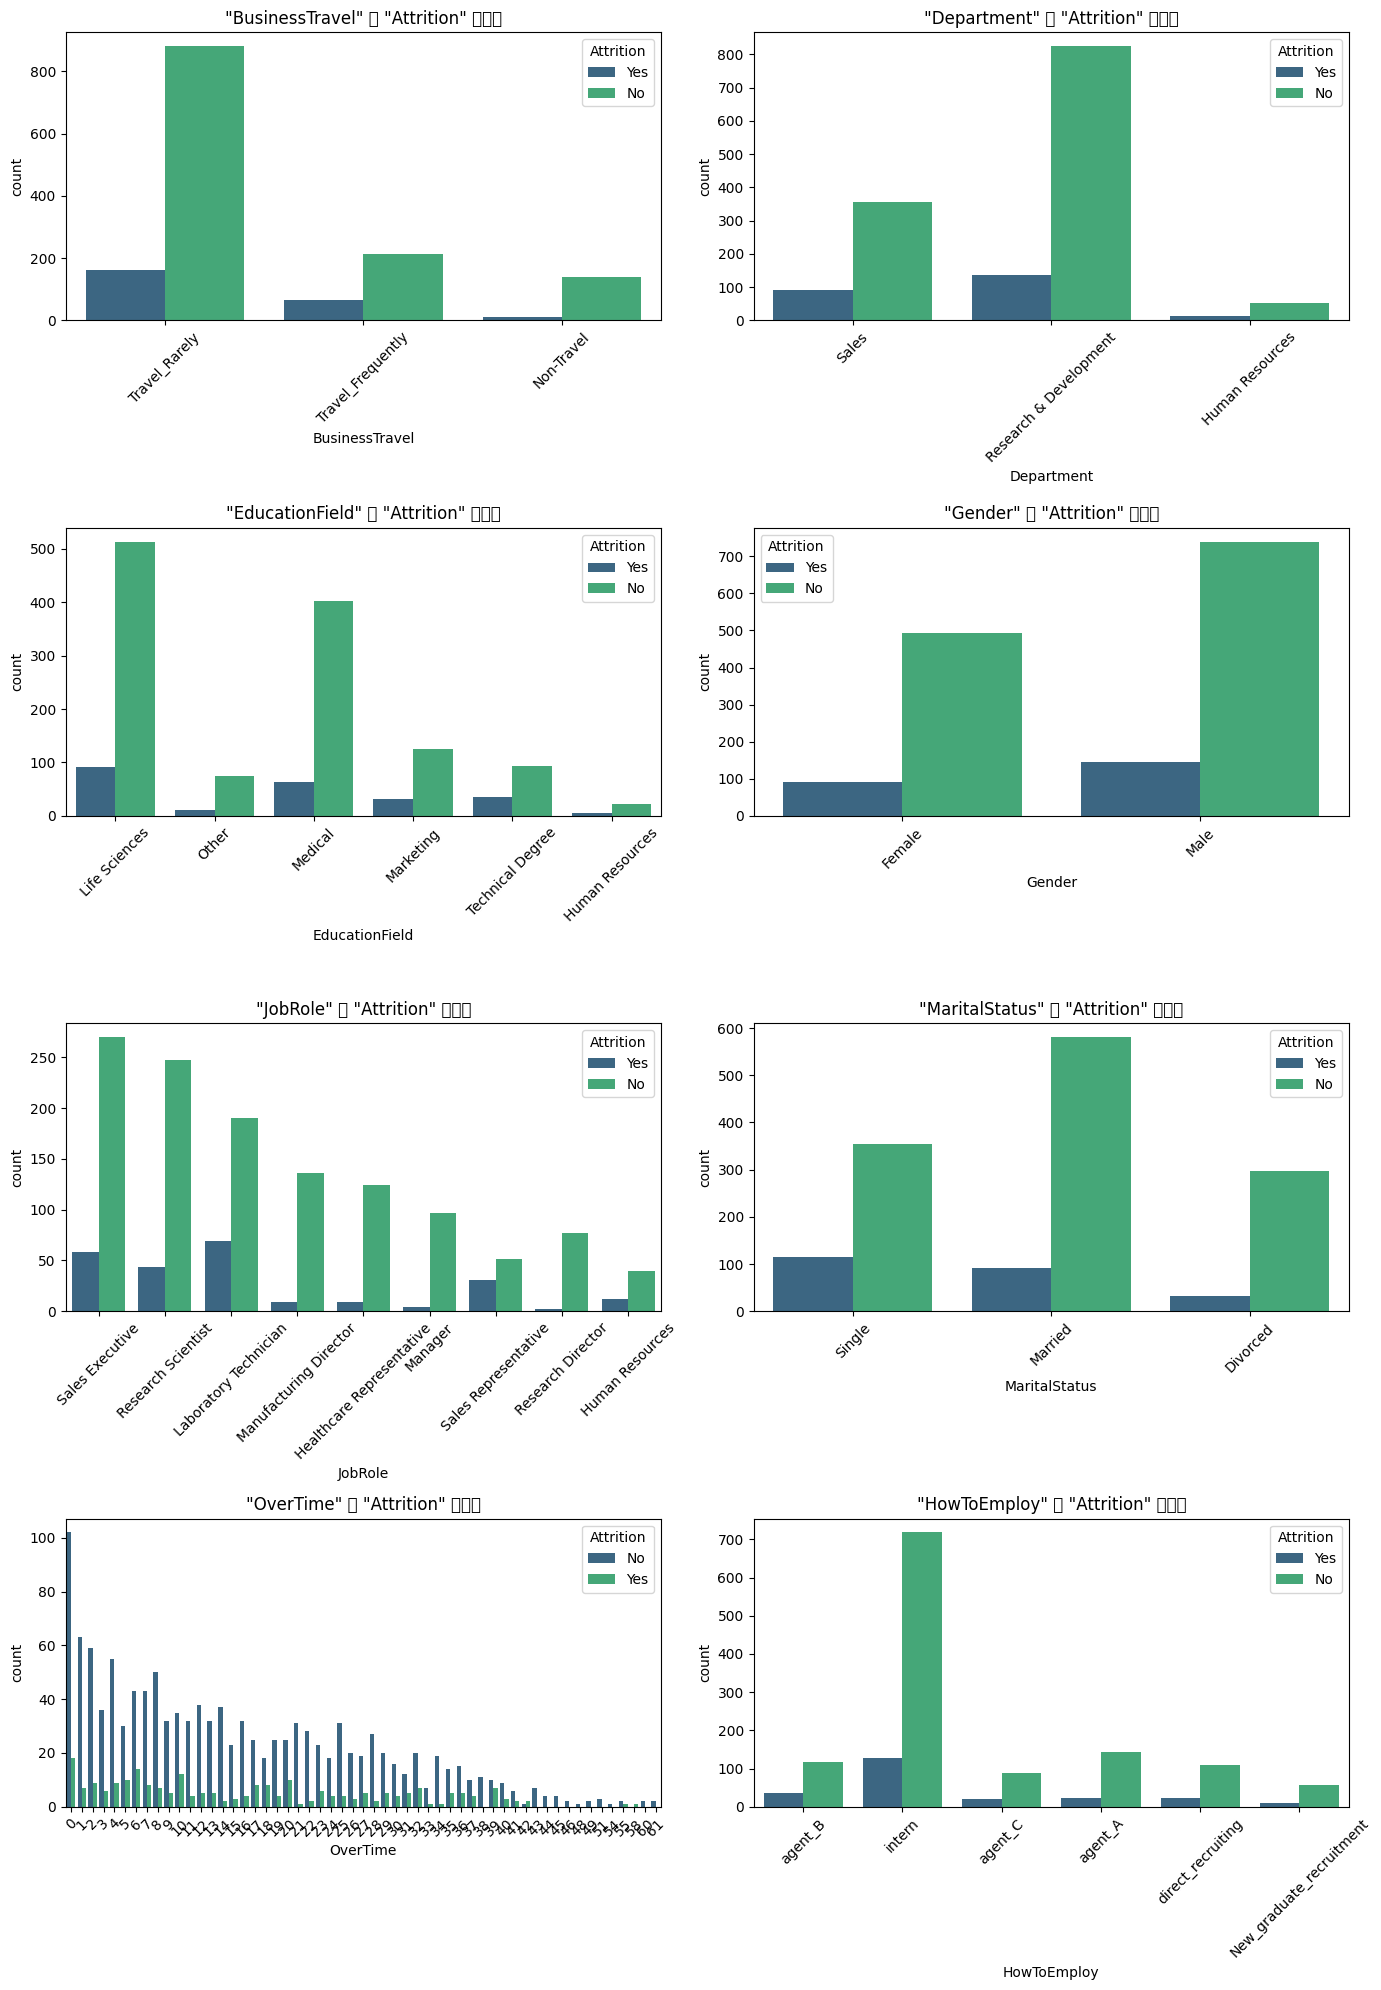

In [ ]:

import math
categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime', 'HowToEmploy'
]


n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)


fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))

axes = axes.flatten()

# --- 各グラフを描画 ---
for i, col in enumerate(categorical_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, hue='Attrition', palette='viridis', ax=ax)
    ax.set_title(f'"{col}" と "Attrition" の関係')
    ax.tick_params(axis='x', rotation=45)

# --- 余ったグラフを非表示にする ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.tight_layout() # レイアウトを自動調整してくれるやつ
plt.show()


In [ ]:
df['OverTime'].unique()

array([16,  7, 32, 28, 10, 14,  0, 24,  5,  4, 43, 20, 23, 11, 31,  3,  8,
       34, 15, 22, 17, 35, 39,  1,  6, 18, 12, 30, 38, 25, 33, 19, 13, 21,
       29, 46,  2,  9, 27, 26, 51, 36, 60, 42, 45, 41, 37, 44, 40, 54, 48,
       49, 55, 61, 58])

/tmp/ipython-input-9-1565648840.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='pastel', ax=ax)
/tmp/ipython-input-9-1565648840.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='pastel', ax=ax)
/tmp/ipython-input-9-1565648840.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y=col, palette='pastel', ax=ax)
/tmp/ipython-input-9-1565648840.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

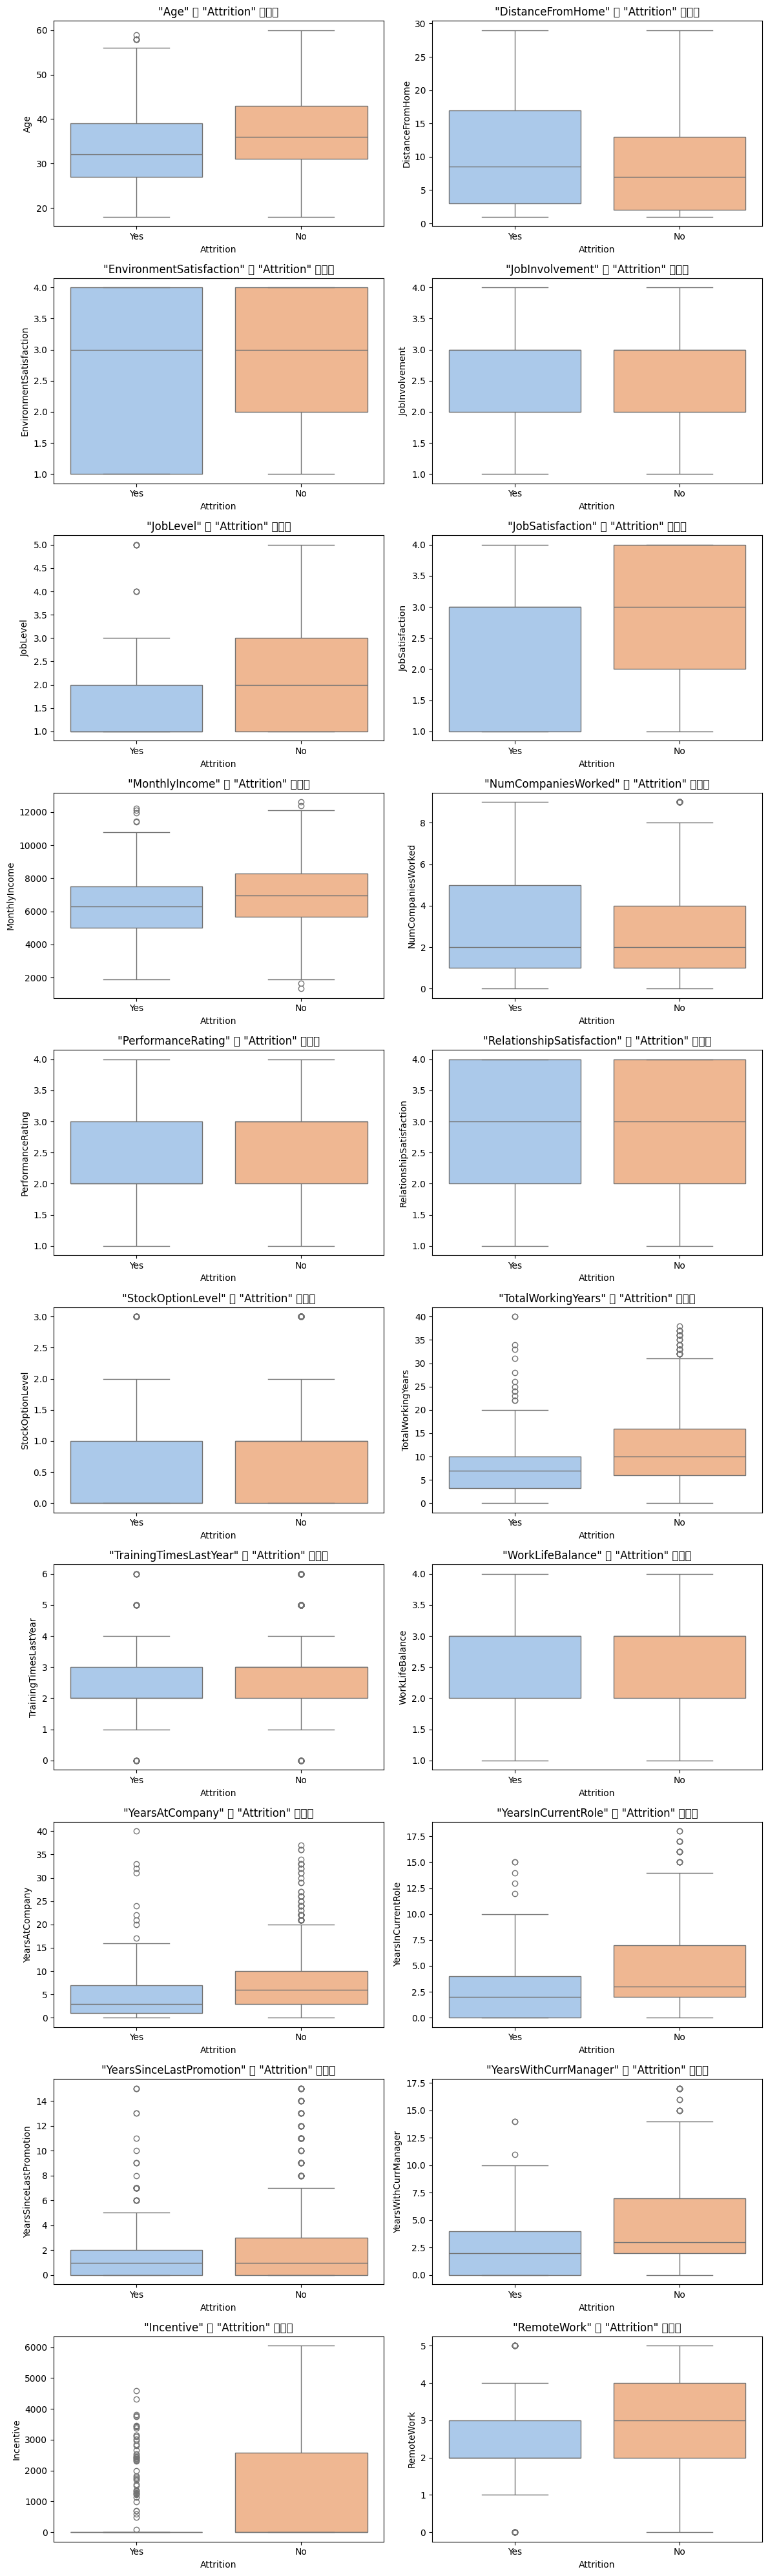

In [ ]:

import math


numerical_cols = [
    'Age', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked',
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'Incentive', 'RemoteWork'
]


n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))

axes = axes.flatten()


for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='Attrition', y=col, palette='pastel', ax=ax)
    ax.set_title(f'"{col}" と "Attrition" の関係')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.tight_layout()
plt.show()

In [ ]:
#可視化

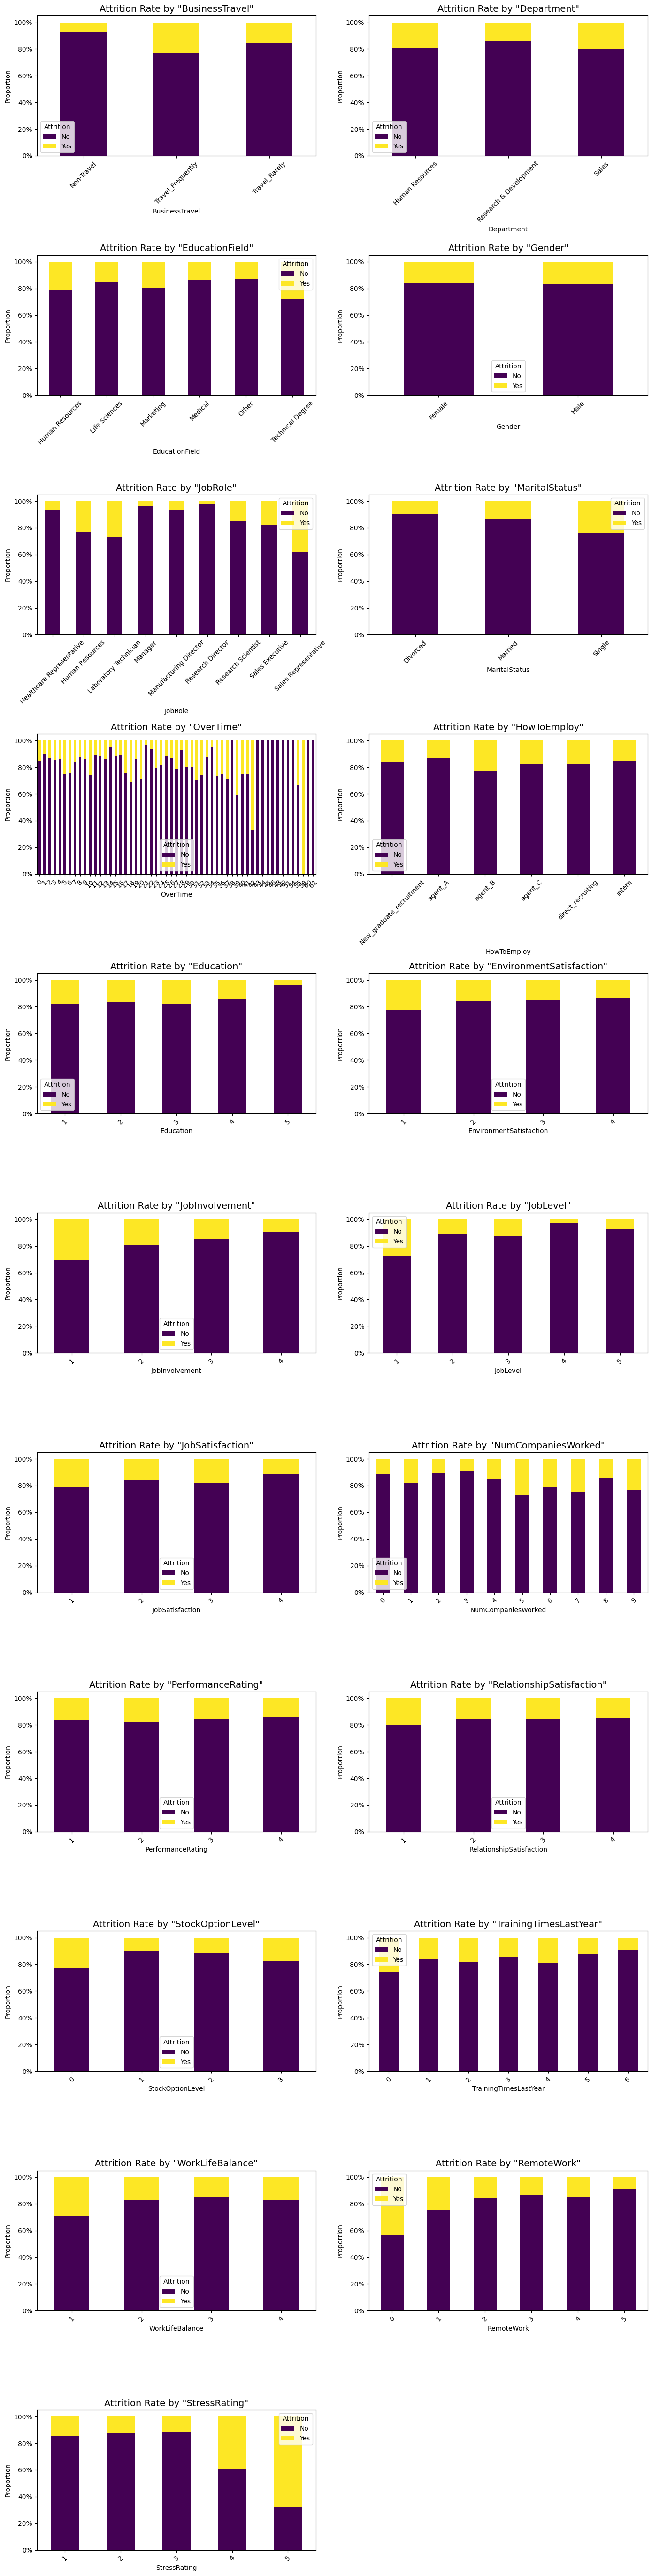

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math


direct_plot_cols = [

    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
    'MaritalStatus', 'OverTime', 'HowToEmploy',

    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'RemoteWork', 'StressRating'
]


n_cols = 2
n_rows = math.ceil(len(direct_plot_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()


for i, col in enumerate(direct_plot_cols):
    ax = axes[i]
    crosstab_df = pd.crosstab(df[col], df['Attrition'])
    rate_df = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)
    rate_df.plot(kind='bar', stacked=True, colormap='viridis', ax=ax)

   -
    ax.set_title(f'Attrition Rate by "{col}"', fontsize=14)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend(title='Attrition')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.tight_layout()
plt.show()

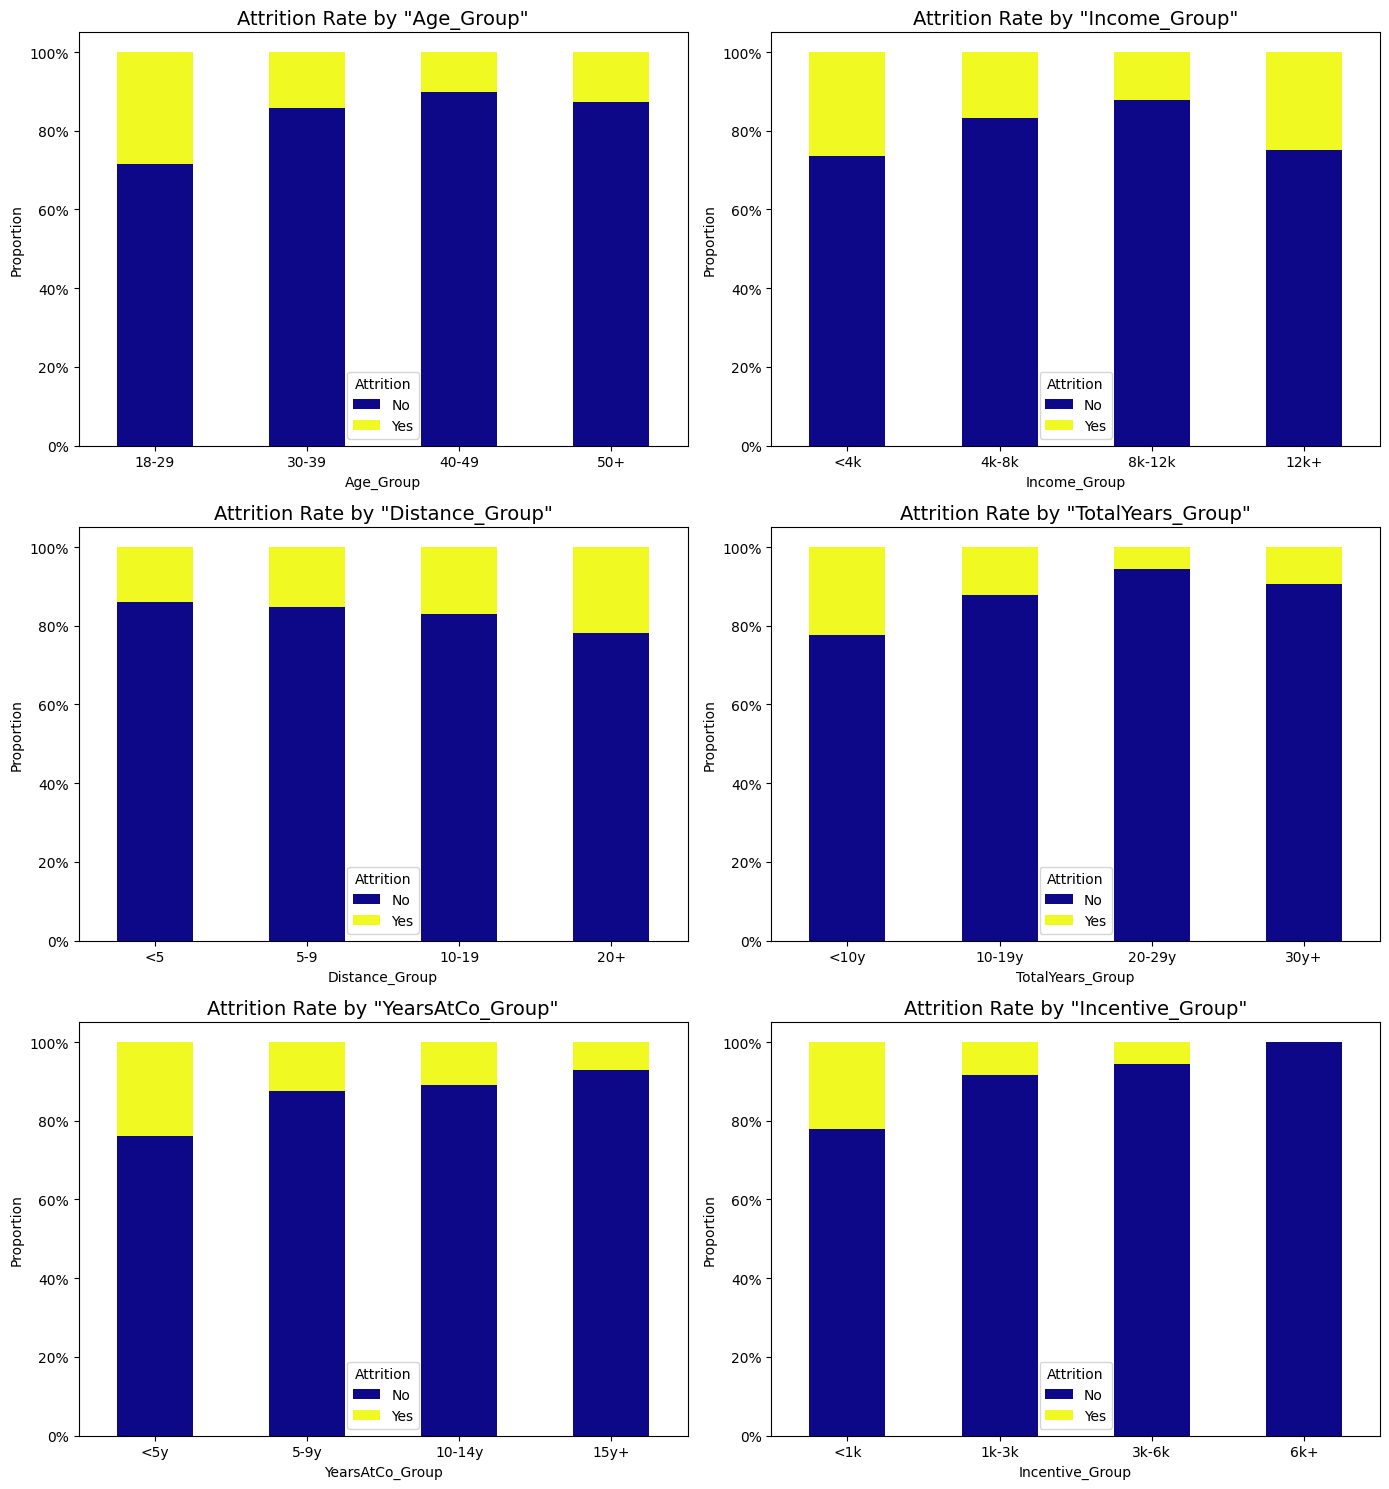

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import math


binning_settings = {
    'Age_Group': {'column': 'Age', 'bins': [18, 30, 40, 50, 61], 'labels': ['18-29', '30-39', '40-49', '50+']},
    'Income_Group': {'column': 'MonthlyIncome', 'bins': [0, 4000, 8000, 12000, float('inf')], 'labels': ['<4k', '4k-8k', '8k-12k', '12k+']},
    'Distance_Group': {'column': 'DistanceFromHome', 'bins': [0, 5, 10, 20, float('inf')], 'labels': ['<5', '5-9', '10-19', '20+']},
    'TotalYears_Group': {'column': 'TotalWorkingYears', 'bins': [0, 10, 20, 30, float('inf')], 'labels': ['<10y', '10-19y', '20-29y', '30y+']},
    'YearsAtCo_Group': {'column': 'YearsAtCompany', 'bins': [0, 5, 10, 15, float('inf')], 'labels': ['<5y', '5-9y', '10-14y', '15y+']},
    'Incentive_Group': {'column': 'Incentive', 'bins': [0, 1000, 3000, 6000, float('inf')], 'labels': ['<1k', '1k-3k', '3k-6k', '6k+']}
}


binned_cols = list(binning_settings.keys())
for new_col, setting in binning_settings.items():
    df[new_col] = pd.cut(df[setting['column']], bins=setting['bins'], labels=setting['labels'], right=False)


n_cols = 2
n_rows = math.ceil(len(binned_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()


for i, col in enumerate(binned_cols):
    ax = axes[i]
    crosstab_df = pd.crosstab(df[col], df['Attrition'])
    rate_df = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)
    rate_df.plot(kind='bar', stacked=True, colormap='plasma', ax=ax)


    ax.set_title(f'Attrition Rate by "{col}"', fontsize=14)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.legend(title='Attrition')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.tight_layout()
plt.show()

In [ ]:
# クロス集計を実行
#お試しコード
cross_table = pd.crosstab(df['Attrition'], [df['MonthlyIncome'],df['Incentive']])

print(cross_table)

MonthlyIncome 1329  1666  1873  1875  2094  2228  2255  2317  2370  2410   \
Incentive      631   791   0     0     994   0     0     0     0     1144   
Attrition                                                                   
No                1     1     1     0     1     1     1     0     1     1   
Yes               0     0     0     1     0     0     0     1     0     0   

MonthlyIncome  ... 11901 11948 12032 12049 12094 12117 12129 12245 12391 12612  
Incentive      ...  0     2389  5715  0     6047  0     2425  0     0     0     
Attrition      ...                                                              
No             ...     1     0     1     1     1     1     0     0     1     1  
Yes            ...     0     1     0     0     0     0     1     1     0     0  

[2 rows x 1422 columns]


In [ ]:
# 'JobRole'で絞り込み、'Stress Rating' の各値の出現回数を直接数える
stress_counts_simple = df[df['JobRole'] == 'Sales Representative']['StressRating'].value_counts()

print(stress_counts_simple)

StressRating
2    36
3    24
1     9
4     9
5     4
Name: count, dtype: int64


   StressRating  Count
0             1      9
1             2     36
2             3     24
3             4      9
4             5      4


/tmp/ipython-input-23-3775353679.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sales_reps_df, x='StressRating', palette='magma')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473

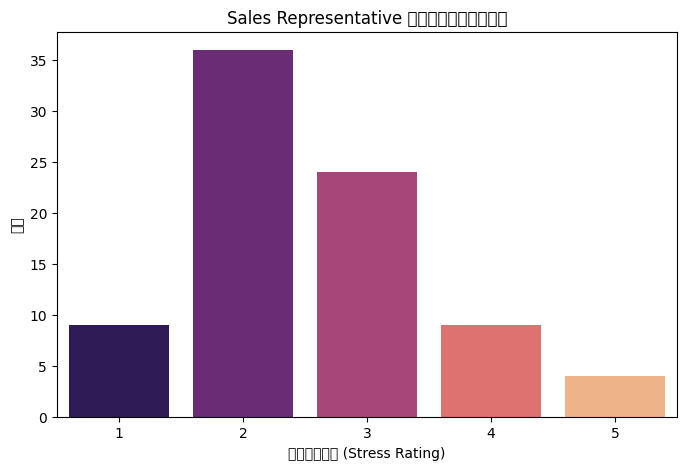

In [ ]:
#  'JobRole' が 'Sales Representative' のデータに絞り込む
sales_reps_df = df[df['JobRole'] == 'Sales Representative']

#  'Stress Rating' ごとにグループ化して、人数を数える
stress_counts = sales_reps_df.groupby('StressRating').size().reset_index(name='Count')

print(stress_counts)
import seaborn as sns
import matplotlib.pyplot as plt

# 上で絞り込んだ 'sales_reps_df' を使う
plt.figure(figsize=(8, 5))
sns.countplot(data=sales_reps_df, x='StressRating', palette='magma')
plt.title('Sales Representative のストレス評価の分布')
plt.xlabel('ストレス評価 (Stress Rating)')
plt.ylabel('人数')
plt.show()

/tmp/ipython-input-26-665331448.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=job_reps_df, x='JobRole', palette='magma')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATA

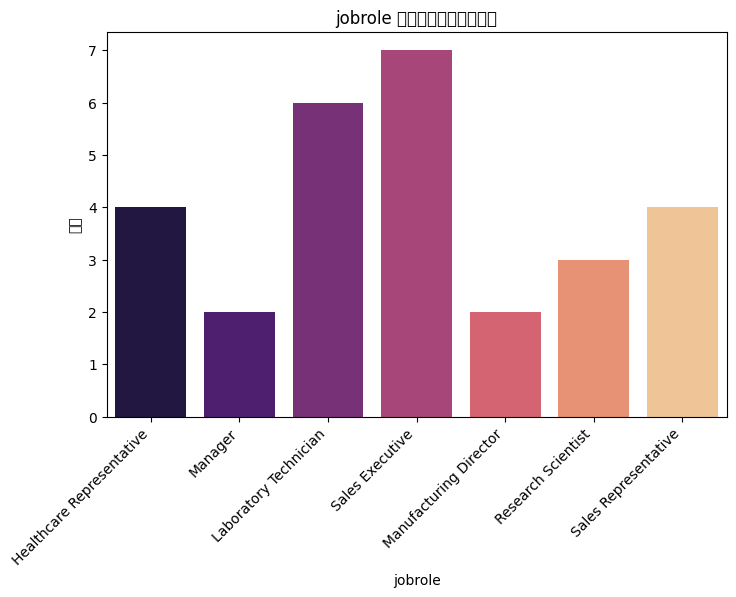

In [ ]:
job_reps_df = df[df['StressRating'] == 5]


stress_counts = job_reps_df.groupby('JobRole').size().reset_index(name='Count')


plt.figure(figsize=(8, 5))
sns.countplot(data=job_reps_df, x='JobRole', palette='magma')
plt.title('jobrole のストレス評価の分布')
plt.xlabel('jobrole')
plt.ylabel('人数')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 32887 (\N{CJK UNIFIED IDEOGRAPH-8077}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-28-3478779035.py:36: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH

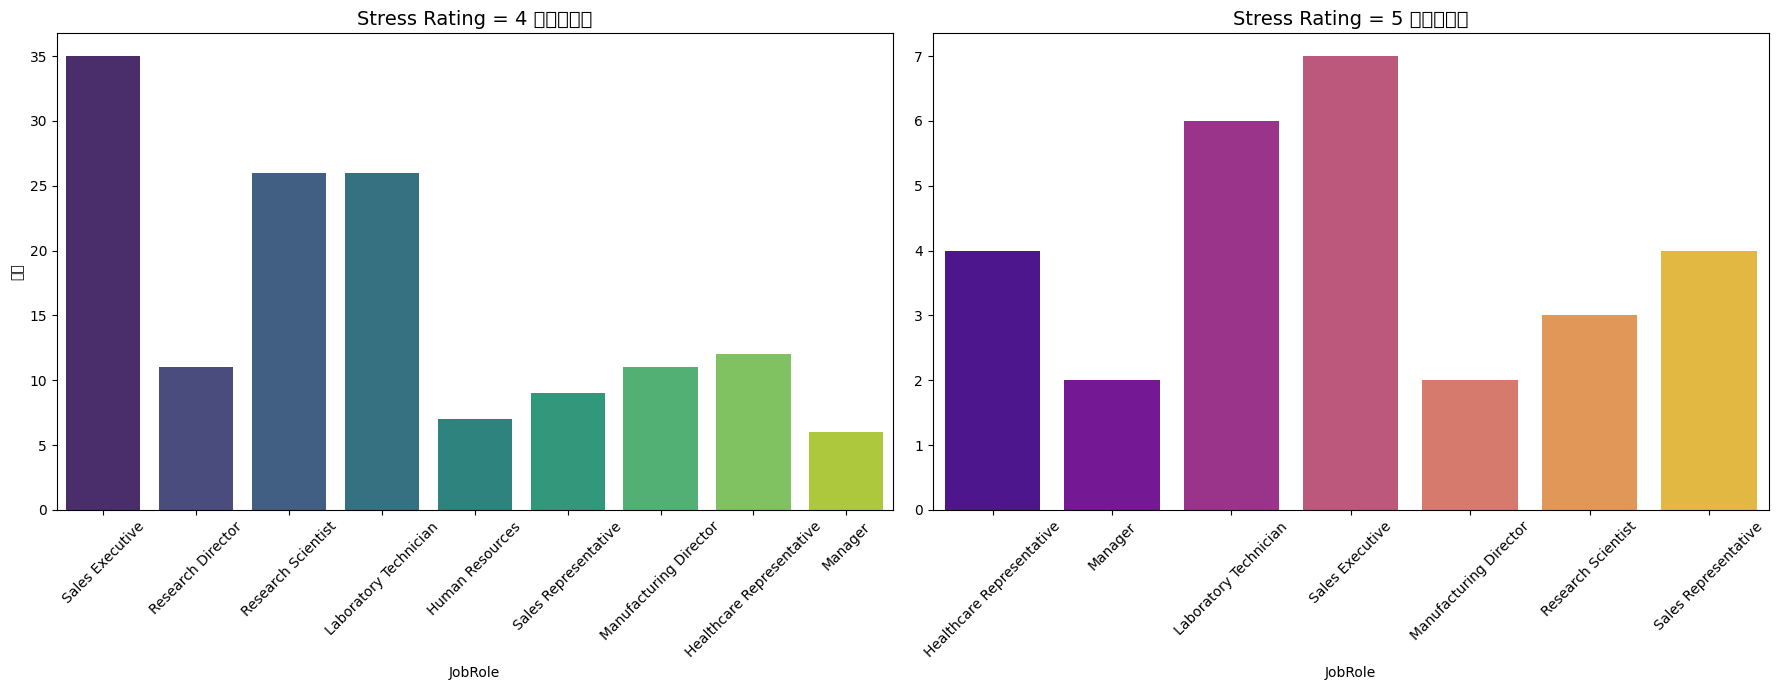

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


ax1 = axes[0]
stress_4_df = df[df['StressRating'] == 4]


sns.countplot(data=stress_4_df, x='JobRole', hue='JobRole', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Stress Rating = 4 の職種分布', fontsize=14)
ax1.set_xlabel('JobRole')
ax1.set_ylabel('人数')

ax1.tick_params(axis='x', rotation=45, labelsize=10)



ax2 = axes[1]
stress_5_df = df[df['StressRating'] == 5]


sns.countplot(data=stress_5_df, x='JobRole', hue='JobRole', palette='plasma', ax=ax2, legend=False)
ax2.set_title('Stress Rating = 5 の職種分布', fontsize=14)
ax2.set_xlabel('JobRole')
ax2.set_ylabel('')

ax2.tick_params(axis='x', rotation=45, labelsize=10)


plt.tight_layout()
plt.show()

In [ ]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

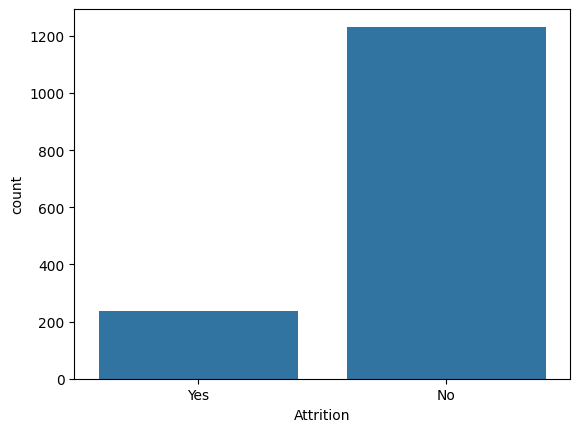

In [ ]:
sns.countplot(x='Attrition', data=df)
plt.show()

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
No,1232
Yes,238


In [ ]:
print(f"No,{df['Attrition'].value_counts()[0]/len(df)*100:.3f}%")
print(f"Yes,{df['Attrition'].value_counts()[1]/len(df)*100:.3f}%")

No,83.810%
Yes,16.190%


/tmp/ipython-input-24-2491488670.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"No,{df['Attrition'].value_counts()[0]/len(df)*100:.3f}%")
/tmp/ipython-input-24-2491488670.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Yes,{df['Attrition'].value_counts()[1]/len(df)*100:.3f}%")


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
#label encodering
col_obj = df.select_dtypes(include='object')
col_obj=list(col_obj.columns)
le=LabelEncoder()
for col in col_obj:
  df[col]=le.fit_transform(df[col])

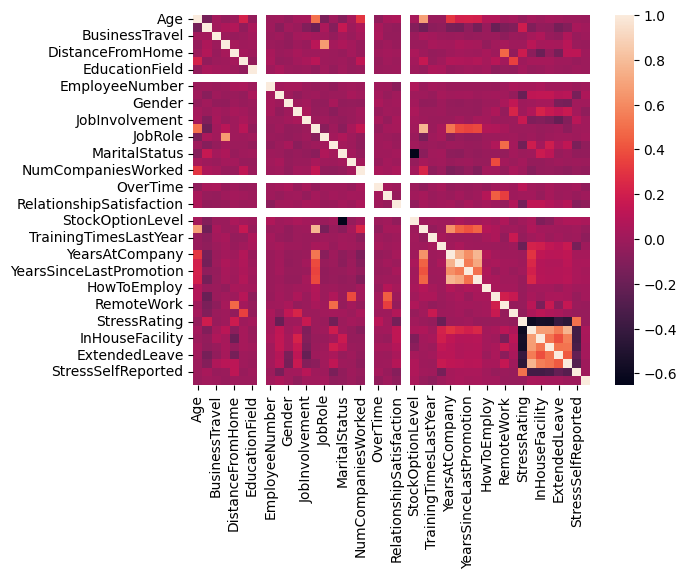

In [ ]:
corr=df.corr()
sns.heatmap(corr,annot=False)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [ ]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.3,random_state=0)

In [ ]:
#お試しAUC
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_valid, y_valid, reference=lgb_train)

# パラメータ
params = {
        'task': 'train',
        'boosting_type': 'gbdt',
        'objective': 'binary', # 目的 : 分類
        'metric': {'auc'},
         'num_leaves': 20,
        'max_depth':5,
        'min_data_in_leaf': 3,
        'num_iteration': 100,
        'learning_rate':0.03,
        'num_boost_round':100,
         'early_stopping_rounds':20,
}

# モデルの学習
model = lgb.train(params,
                  train_set=lgb_train,
                  valid_sets=lgb_eval,
                  )

# テストデータの予測
y_pred = model.predict(X_valid)

[LightGBM] [Info] Number of positive: 163, number of negative: 866
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1355
[LightGBM] [Info] Number of data points in the train set: 1029, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158406 -> initscore=-1.670135
[LightGBM] [Info] Start training from score -1.670135
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[44]	valid_0's auc: 0.807887


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

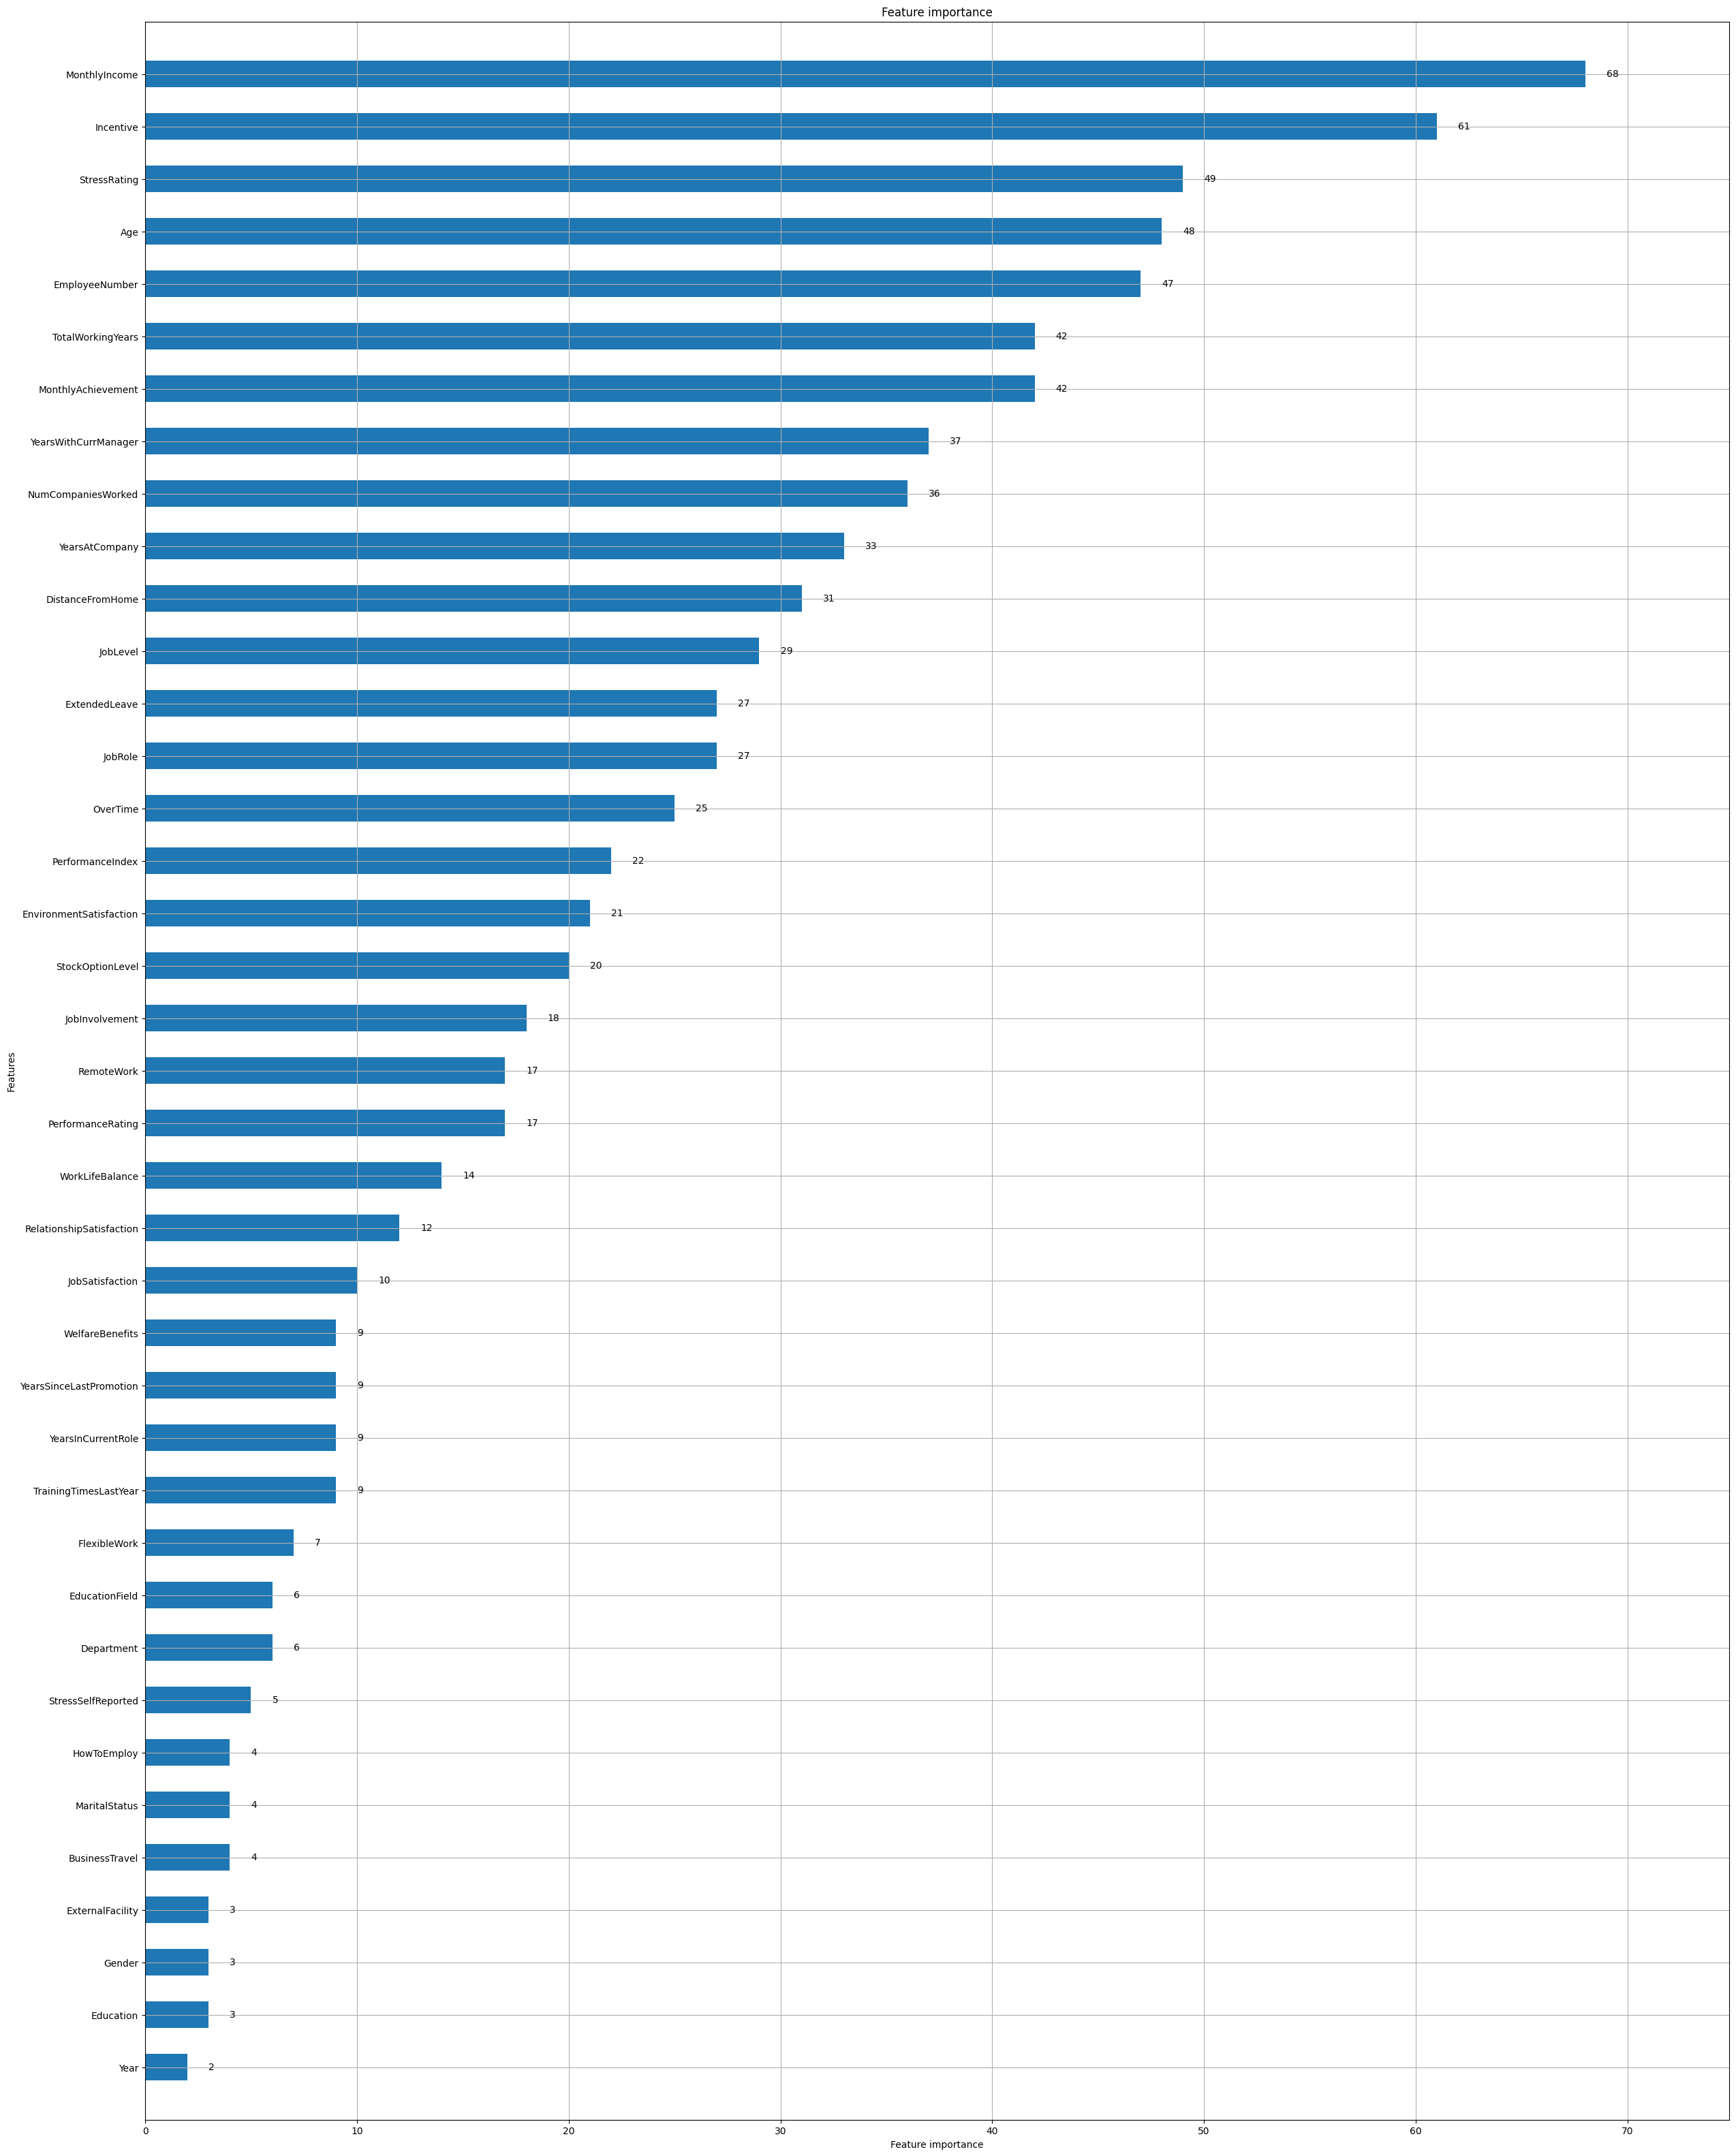

In [ ]:
lgb.plot_importance(model, height=0.5, figsize=(30,40))

In [ ]:
#ベースライン？
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, n_redundant=5, random_state=42)
X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(20)])


X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_valid, y_valid, reference=lgb_train)


params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'num_leaves': 20,
    'max_depth': 5,
    'min_child_samples': 20,
    'seed': 42,
    'verbose': -1
}



model = lgb.train(
    params,
    train_set=lgb_train,
    valid_sets=[lgb_train, lgb_eval],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=True)] # Replaces early_stopping_rounds
)



y_pred_proba = model.predict(X_valid, num_iteration=model.best_iteration)
auc_score = roc_auc_score(y_valid, y_pred_proba)

print(f"Baseline AUC Score: {auc_score:.4f}")


lgb.plot_importance(model, importance_type='gain', max_num_features=15, figsize=(10, 8))
plt.title('Feature Importance (Baseline Model)')
plt.show()